# 1. Importing necessary libraries and dataset with engineered features

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta

%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

In [3]:
#Importing the Dataframe with the features

df = pd.read_csv('/Users/arthurassis/Documents/CCT - Data Analytics for Business/Machine Learning/Semester 2/CA01-MachineLearning-Semester2/CA01-MachineLearning/Python-Forecasting-Electrical-Demand-on-Spain/part_2_output_features_engineered.csv',
                parse_dates = ['timestamp'])

In [4]:
#Setting the timestamp as the index

df.set_index('timestamp', inplace = True)

# 2. Setting baselines

In [5]:
#Defining the train and test dataset

df_train_validation = df.loc['2015-01-01 00:00:00':'2017-12-31 23:00:00']
df_test = df.loc['2018-01-01 00:00:00':'2018-04-01 00:00:00']

In [6]:
#Calculating the mean of total load actual considering the previous 2 weeks

twoweekmean = np.mean(df_train_validation['total load actual'][-336:])
df_test['twoweekmean'] = twoweekmean

The next baseline will consider the seasonal nature of the dataset and make a naive prediction of it, considering the following 3 months follow the same values as the past 3 months.

In [7]:
len(df_test)

2161

In [8]:
df_train_validation.iloc[-2161:]

,total load actual,total load forecast,year,month,doy,dom,dow,woy,hour,is_leap_year,...,month_cos,doy_sin,doy_cos,woy_sin,woy_cos,season,is_weekend,is_end_of_year,is_christmas,is_holiday
timestamp,,,,,,,,,,,,,,,,,,,,,
2017-10-02 23:00:00,30334.0,30470.0,2017,10,275,2,0,40,23,False,...,0.5,-9.997685e-01,0.021516,-9.927089e-01,0.120537,Autumn,False,False,False,0
2017-10-03 00:00:00,25700.0,25910.0,2017,10,276,3,1,40,0,False,...,0.5,-9.992500e-01,0.038722,-9.927089e-01,0.120537,Autumn,False,False,False,0
2017-10-03 01:00:00,24273.0,24347.0,2017,10,276,3,1,40,1,False,...,0.5,-9.992500e-01,0.038722,-9.927089e-01,0.120537,Autumn,False,False,False,0
2017-10-03 02:00:00,23323.0,23291.0,2017,10,276,3,1,40,2,False,...,0.5,-9.992500e-01,0.038722,-9.927089e-01,0.120537,Autumn,False,False,False,0
2017-10-03 03:00:00,22994.0,22896.0,2017,10,276,3,1,40,3,False,...,0.5,-9.992500e-01,0.038722,-9.927089e-01,0.120537,Autumn,False,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-12-31 19:00:00,29097.0,29226.0,2017,12,365,31,6,52,19,False,...,1.0,6.432491e-16,1.000000,6.432491e-16,1.000000,Winter,True,True,False,0
2017-12-31 20:00:00,28666.0,29107.0,2017,12,365,31,6,52,20,False,...,1.0,6.432491e-16,1.000000,6.432491e-16,1.000000,Winter,True,True,False,0
2017-12-31 21:00:00,27260.0,27453.0,2017,12,365,31,6,52,21,False,...,1.0,6.432491e-16,1.000000,6.432491e-16,1.000000,Winter,True,True,False,0


In [9]:
#Adding a Seasonsal Naive Forecast to the dataset
df_test['seasonal_naive'] = df_train_validation.iloc[-2161:]['total load actual'].values

The next baseline will also be based in the seasonal nature of the dataset, but instead of getting the same values from the previous week, we will add the same values from the same doy, month and hour, from the previous year. 

In [10]:
#PSelecting the same period of the previous year as a baseline

df_test['seasonal_naive_last_year'] = df_train_validation.loc['2017-01-01 00:00:00':'2017-04-01 00:00:00']['total load actual'].values

## 2.1. Visualising baselines against data

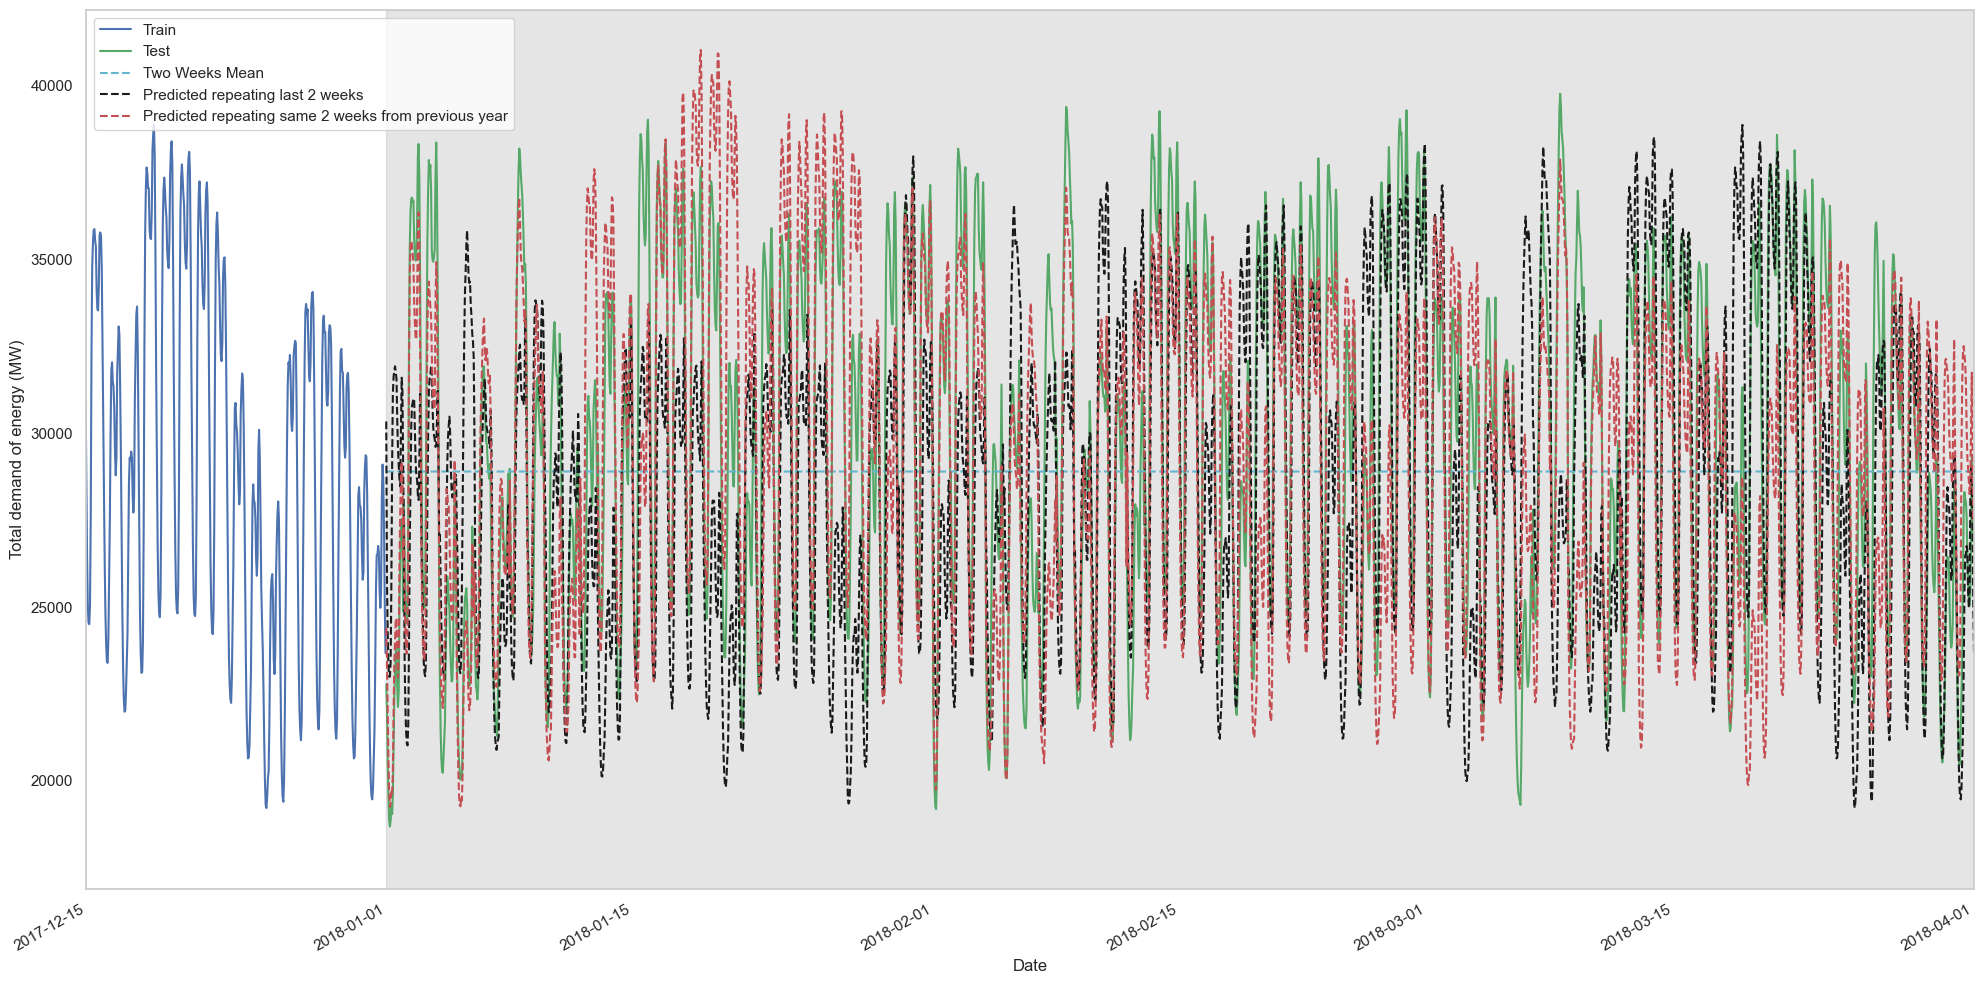

In [51]:
#Ploting our baselines in a graph
sns.set(rc={"figure.figsize":(20,10)})
sns.set_style('whitegrid')
fig, ax = plt.subplots()

ax.plot(df_train_validation.index, df_train_validation['total load actual'], 'b', label='Train')
ax.plot(df_test.index, df_test['total load actual'], 'g-', label='Test')
ax.plot(df_test.index, df_test['twoweekmean'], 'c--', label='Two Weeks Mean')
ax.plot(df_test.index, df_test['seasonal_naive'], 'k--', label='Predicted repeating last 2 weeks')
ax.plot(df_test.index, df_test['seasonal_naive_last_year'], 'r--', label='Predicted repeating same 2 weeks from previous year')

x_start = pd.to_datetime('2017-12-15 00:00:00')
x_end = pd.to_datetime('2018-04-01 00:00:00')
ax.set_xlim(x_start, x_end)
ax.grid(False)

ax.set_xlabel('Date')
ax.set_ylabel('Total demand of energy (MW)')
ax.axvspan('2018-01-01 00:00:00', '2018-04-01 00:00:00', color='#808080', alpha=0.2)
ax.legend(loc=2)

fig.autofmt_xdate()
plt.tight_layout()

So that it is possible to visualise better the graph, a smaller period will be visualised

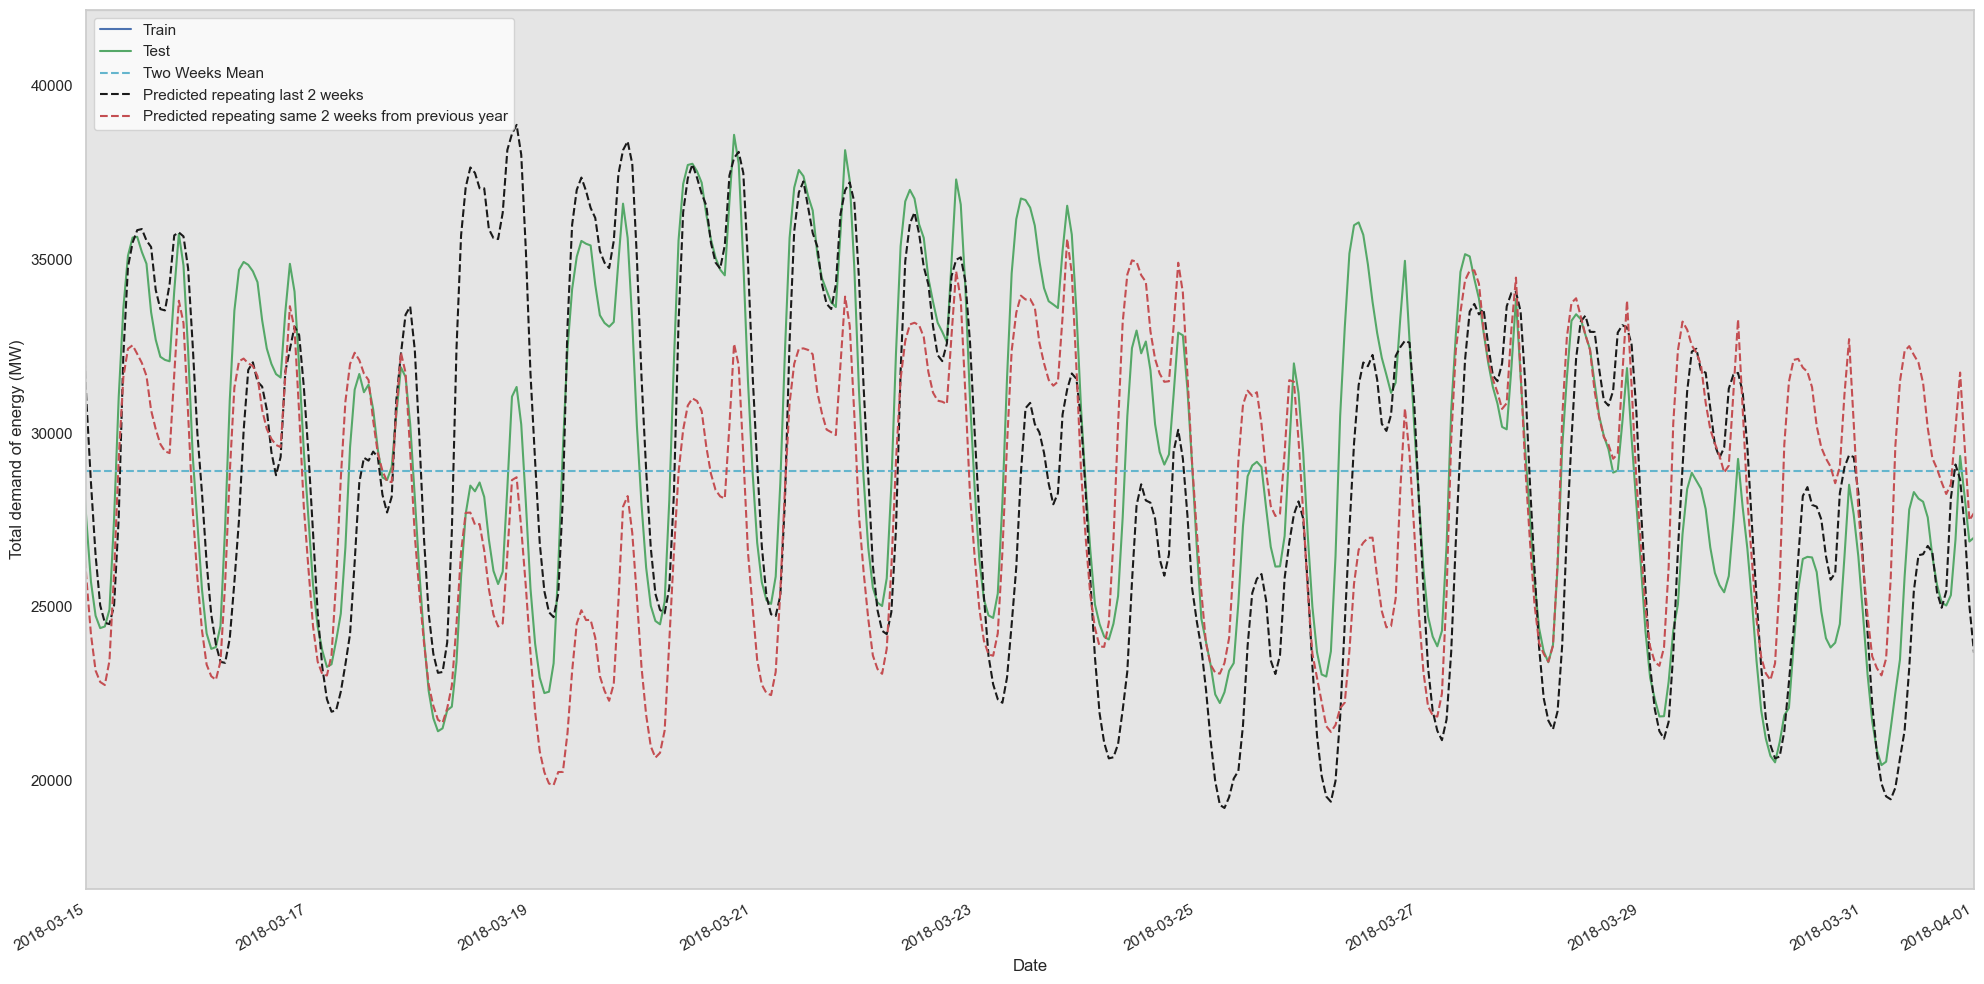

In [53]:
#Ploting our baselines in a graph
sns.set(rc={"figure.figsize":(20,10)})
sns.set_style('whitegrid')
fig, ax = plt.subplots()

ax.plot(df_train_validation.index, df_train_validation['total load actual'], 'b', label='Train')
ax.plot(df_test.index, df_test['total load actual'], 'g-', label='Test')
ax.plot(df_test.index, df_test['twoweekmean'], 'c--', label='Two Weeks Mean')
ax.plot(df_test.index, df_test['seasonal_naive'], 'k--', label='Predicted repeating last 2 weeks')
ax.plot(df_test.index, df_test['seasonal_naive_last_year'], 'r--', label='Predicted repeating same 2 weeks from previous year')

x_start = pd.to_datetime('2018-03-15 00:00:00')
x_end = pd.to_datetime('2018-04-01 00:00:00')
ax.set_xlim(x_start, x_end)
ax.grid(False)

ax.set_xlabel('Date')
ax.set_ylabel('Total demand of energy (MW)')
ax.axvspan('2018-01-01 00:00:00', '2018-04-01 00:00:00', color='#808080', alpha=0.2)
ax.legend(loc=2)

fig.autofmt_xdate()
plt.tight_layout()

At certain points the same data from the previous week matches better the results, on other, the last year provides a better forecast. It is necessary to verify which method provides a better fit. To do it so, the metric MAPE will be used.

## 2.2. Defining MAPE to evaluate the models

In [12]:
#Defining a function to calculate MAPE
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [13]:
#Defining a dataset to hold the results of the models created

mape_results= pd.DataFrame(columns = ['Method', 'MAPE'])

In [14]:
#Adding twoweekmean method's MAPE

mape_results.loc[len(mape_results)] = ['twoweekmean', mape(df_test['total load actual'], df_test['twoweekmean'])]

In [15]:
df_test.columns

Index(['total load actual', 'total load forecast', 'year', 'month', 'doy',
       'dom', 'dow', 'woy', 'hour', 'is_leap_year', 'hour_sin', 'hour_cos',
       'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos',
       'woy_sin', 'woy_cos', 'season', 'is_weekend', 'is_end_of_year',
       'is_christmas', 'is_holiday', 'twoweekmean', 'seasonal_naive',
       'seasonal_naive_last_year'],
      dtype='object')

# 3. Evaluating the methods

In [16]:
#Adding seasonal_naive method's MAPE

mape_results.loc[len(mape_results)] = ['seasonal_naive', mape(df_test['total load actual'], 
                                                              df_test['seasonal_naive'])]

In [17]:
#Adding seasonal_naive_last_year method's MAPE

mape_results.loc[len(mape_results)] = ['seasonal_naive_last_year', mape(df_test['total load actual'], 
                                                              df_test['seasonal_naive_last_year'])]

In [18]:
#Printing the results so far

mape_results.head()

,Method,MAPE
0,twoweekmean,14.609220
1,seasonal_naive,11.049250
2,seasonal_naive_last_year,8.245863


In [20]:
#Creating the dictionaries to add the results in the dataframe

SARIMAX_results = {
    'Method': 'SARIMAX',
    'MAPE': 9.89
}

UC_results = {
    'Method': 'Unobserved Components',
    'MAPE': 7.96
}

LightGBM_results = {
    'Method': 'LightGBM',
    'MAPE': 5.85
}

In [21]:
#Adding SARIMAX results

mape_results.loc[len(mape_results)] = pd.Series(SARIMAX_results)

In [22]:
#Adding UC results

mape_results.loc[len(mape_results)] = pd.Series(UC_results)

In [23]:
#Adding LightGBM results

mape_results.loc[len(mape_results)] = pd.Series(LightGBM_results)

In [26]:
#Rounding the results to 2 decimals

mape_results['MAPE'] = mape_results['MAPE'].apply(lambda x: round(x, 2))

In [27]:
#Printing the results

mape_results

,Method,MAPE
0,twoweekmean,14.61
1,seasonal_naive,11.05
2,seasonal_naive_last_year,8.25
3,SARIMAX,9.89
4,Unobserved Components,7.96
5,LightGBM,5.85


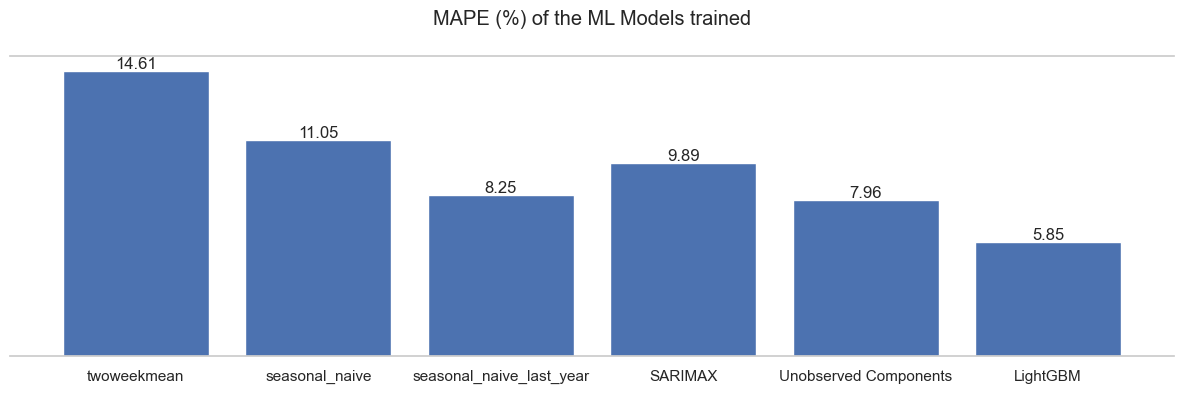

In [49]:
#Visualising the results

fig, ax = plt.subplots(figsize = (12,4))

bars = ax.bar(mape_results['Method'], mape_results['MAPE'])
ax.bar_label(bars, labels = mape_results['MAPE'], padding = 0)

ax.grid(False)
ax.set_yticks([])
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)    
ax.spines['bottom'].set_visible(True)  

fig.suptitle('MAPE (%) of the ML Models trained')
fig.tight_layout()
fig.show()

LightGBM presents the 